# Импорт библиотек и фреймворка


In [1]:
from framework import *

import numpy as np
import pandas as pd
from pathlib import Path
import sympy as sp

# Демонстрация работы фреймворка

Для проверки работоспособности разработанного фреймворка выполним один вычислительный эксперимент с использованием параметров модели и параметров численного моделирования, заданных по умолчанию.

В ходе выполнения эксперимента автоматически будут выполнены следующие этапы:

- вычисление координат положения равновесия модели;
- построение замкнутой системы дифференциальных уравнений с законом управления;
- численное интегрирование системы на заданном временном интервале;
- вычисление всех метрик качества управления;
- построение стандартных графиков, характеризующих динамику системы.

In [2]:
cfg = ExperimentConfig(
    name="Base experiment"
)

result = run_experiment(cfg)

print("Метрики эксперимента:\n")

print(f"Время сходимости (τ):       {result.metrics.tau:.6f}")
print(f"Максимальное |ψ|:           {result.metrics.max_psi:.6f}")
print(f"Максимальное |u|:           {result.metrics.max_u:.6f}")
print(f"Остаточная ошибка:          {result.metrics.e_final:.6e}")

Метрики эксперимента:

Время сходимости (τ):       4.610461
Максимальное |ψ|:           10.000000
Максимальное |u|:           25.000000
Остаточная ошибка:          3.098370e-07


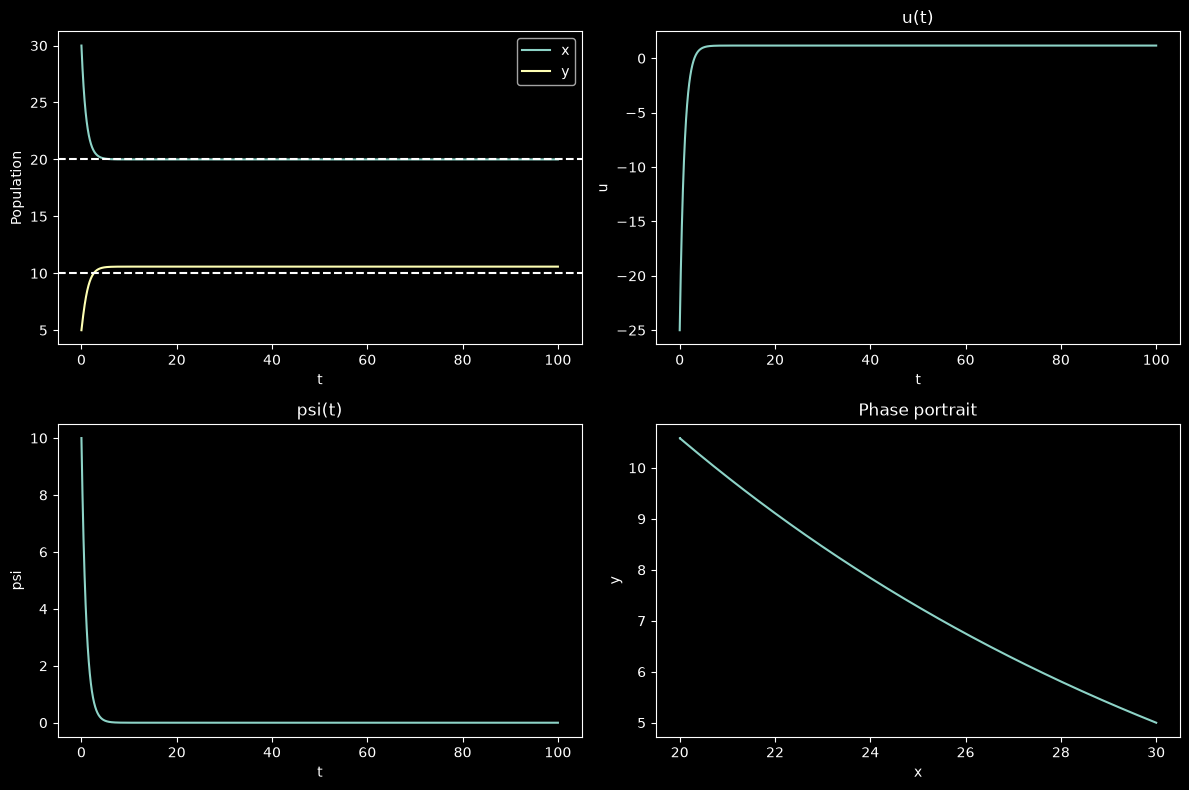

In [3]:
plot_experiment(result)

### Анализ результатов

Система быстро выходит на заданное положение равновесия. Численность жертв уменьшается с 30 до 20 особей, а численность хищников увеличивается с 5 до 10 особей. После этого обе популяции практически не изменяются, что говорит об устойчивости системы.

График ошибки $\psi(t)$ показывает, что отклонение от равновесия быстро уменьшается.

На графике управления видно, что в начальный момент регулятор создаёт достаточно сильное воздействие, чтобы быстро перевести систему в состояние равновесия. Затем величина управления останавливается и остаётся практически постоянной, так как необходимость в дальнейшем интенсивном воздействии исчезает.

Фазовый портрет показывает плавное движение системы к положению равновесия без заметных колебаний, что также подтверждает устойчивость закона управления

Остаточная ошибка имеет очень малое значение, поэтому к концу моделирования система практически полностью достигает заданного состояния равновесия.


# Демонстрация мультипликативного управления

В предыдущем разделе была рассмотрена работа АКАР-регулятора с **аддитивным управлением**. Далее продемонстрируем работу фреймворка для **мультипликативного управления**, при котором управление изменяет коэффициент взаимодействия между популяциями.

После этого сравним оба варианта управления по динамике ошибки, изменению популяций и величине управляющего воздействия.

In [4]:
# Конфигурация эксперимента с мультипликативным управлением

cfg_mul = ExperimentConfig(
    name="multiplicative",
    control=ControlParams(
        T=1.0,
        control_type="multiplicative"
    )
)

result_mul = run_experiment(cfg_mul)

In [5]:
print("Метрики эксперимента:\n")
m = result_mul.metrics
print(f"Время сходимости (τ):      {m.tau:10.6f}")
print(f"Максимальное |ψ|:          {m.max_psi:10.6f}")
print(f"Максимальное |u|:          {m.max_u:10.6f}")
print(f"Остаточная ошибка:         {m.e_final:10.6e}")

Метрики эксперимента:

Время сходимости (τ):        4.610461
Максимальное |ψ|:           10.000000
Максимальное |u|:            0.266667
Остаточная ошибка:         3.098367e-07


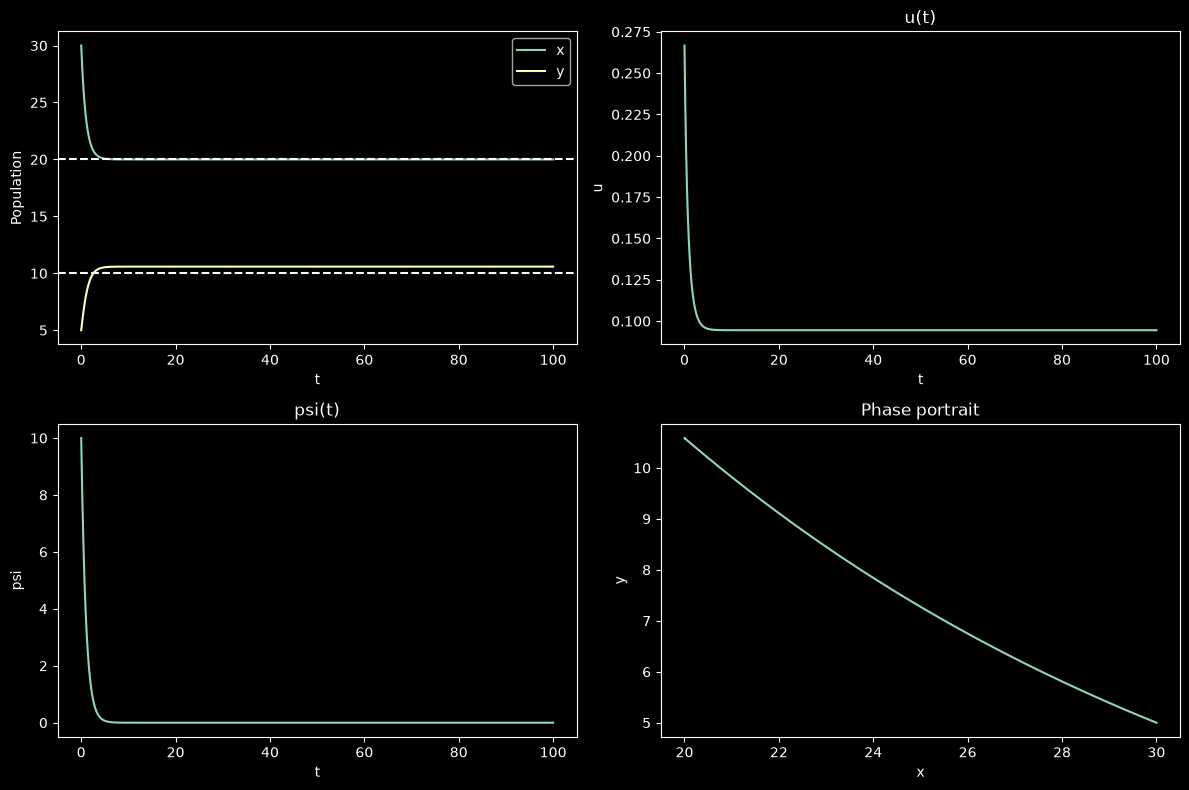

In [6]:
plot_experiment(result_mul)

### Анализ результатов

Полученные результаты практически совпадают с экспериментом для аддитивного управления. Система за то же время достигает положения равновесия, а остаточная ошибка остаётся пренебрежимо малой.

Основное отличие наблюдается только в величине управляющего воздействия, что связано с различным способом его формирования в аддитивном и мультипликативном законах управления.

Более подробное сравнение обоих вариантов управления будет выполнено в следующем разделе.

# Сравнение аддитивного и мультипликативного управления


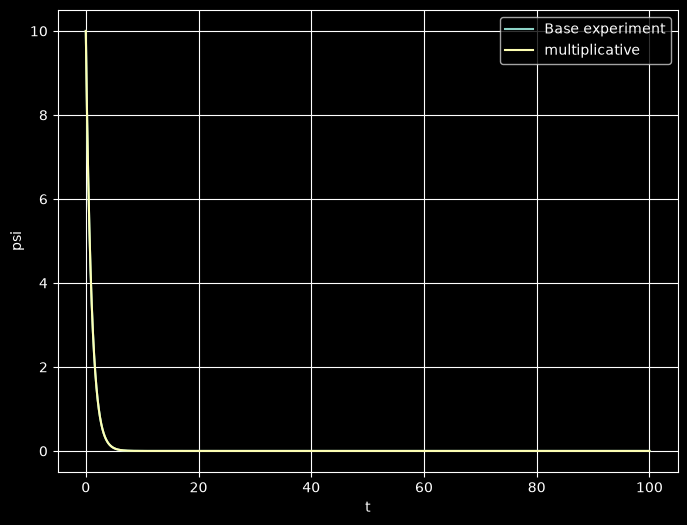

In [7]:
plot_compare(
    [result, result_mul],
    metric="psi"
)

Из графика видно, что кривые для аддитивного и мультипликативного управления полностью совпадают. Это означает, что в обоих случаях ошибка $\psi(t)$ уменьшается с одинаковой скоростью и система достигает положения равновесия за одно и то же время. Следовательно, с точки зрения динамики ошибки оба закона управления обеспечивают одинаковое качество регулирования.

## Сравнение изменения численности популяций x(t)

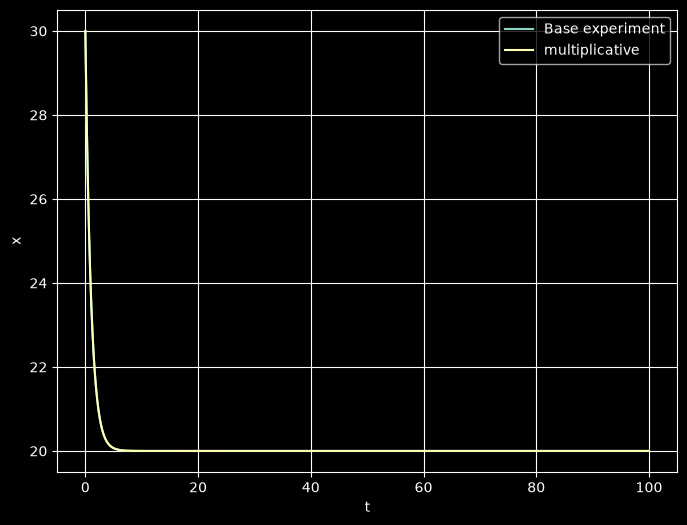

In [8]:
plot_compare(
    [result, result_mul],
    metric="x"
)

Из графика видно, что траектории изменения численности жертв для аддитивного и мультипликативного управления полностью совпадают. В обоих случаях популяция плавно уменьшается до равновесного значения $x^*=20$ без колебаний и перерегулирования.


## Сравнение управляющего воздействия u(t) и сводная таблица результатов

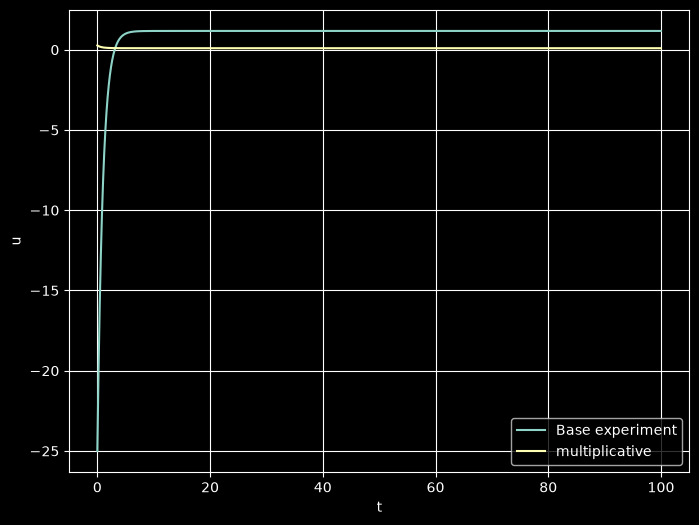

In [9]:
plot_compare(
    [result, result_mul],
    metric="u"
)

In [10]:
print('Сводная таблица результатов')
summary_table([
    result,
    result_mul
])

Сводная таблица результатов
              name    T       tau  max_psi      max_u       e_final
0  Base experiment  1.0  4.610461     10.0  25.000000  3.098370e-07
1   multiplicative  1.0  4.610461     10.0   0.266667  3.098367e-07


Проведённое сравнение показало, что аддитивный и мультипликативный законы управления обеспечивают практически одинаковое качество регулирования. В обоих случаях система достигает положения равновесия за одинаковое время, а значения максимальной и остаточной ошибки практически совпадают.

Основное различие заключается в характере управляющего воздействия. При аддитивном управлении в начальный момент времени требуется значительно большее по величине воздействие, тогда как при мультипликативном управлении управление остаётся существенно меньше. Это связано с тем, что в первом случае управление непосредственно добавляется в уравнение модели, а во втором изменяет коэффициент взаимодействия между популяциями.


# Сохранение и воспроизведение эксперимента

Фреймворк позволяет сохранить параметры эксперимента и вычисленные метрики в JSON-файл. При необходимости эксперимент может быть полностью воспроизведён по сохранённой конфигурации.

In [11]:
save_path = "results/experiment.json"

save_experiment(
    result,
    save_path
)

print("Конфигурация эксперимента успешно сохранена.")

print(f"\nФайл:\n{save_path}")

Конфигурация эксперимента успешно сохранена.

Файл:
results/experiment.json


In [12]:
from pathlib import Path

print("Содержимое папки results:\n")

for file in Path("results").glob("*"):
    print(file.name)

Содержимое папки results:

experiment.json


In [13]:
reproduced = load_and_reproduce(save_path)

In [14]:
print("Исходные метрики:\n")

print(f"Время сходимости (τ):       {result.metrics.tau:.6f}")
print(f"Максимальное |ψ|:           {result.metrics.max_psi:.6f}")
print(f"Максимальное |u|:           {result.metrics.max_u:.6f}")
print(f"Остаточная ошибка:          {result.metrics.e_final:.6e}")

print("\nМетрики эксперимента:")
print(f"Время сходимости (τ):       {result.metrics.tau:.6f}")
print(f"Максимальное |ψ|:           {result.metrics.max_psi:.6f}")
print(f"Максимальное |u|:           {result.metrics.max_u:.6f}")
print(f"Остаточная ошибка:          {result.metrics.e_final:.6e}")

Исходные метрики:

Время сходимости (τ):       4.610461
Максимальное |ψ|:           10.000000
Максимальное |u|:           25.000000
Остаточная ошибка:          3.098370e-07

Метрики эксперимента:
Время сходимости (τ):       4.610461
Максимальное |ψ|:           10.000000
Максимальное |u|:           25.000000
Остаточная ошибка:          3.098370e-07


In [15]:
same = (
    abs(result.metrics.tau - reproduced.metrics.tau) < 1e-8
    and
    abs(result.metrics.max_psi - reproduced.metrics.max_psi) < 1e-8
    and
    abs(result.metrics.max_u - reproduced.metrics.max_u) < 1e-8
    and
    abs(result.metrics.e_final - reproduced.metrics.e_final) < 1e-8
)

print(f"\nСовпадают: {same}")


Совпадают: True


После загрузки конфигурации из JSON-файла эксперимент был автоматически воспроизведён.
Совпадение всех вычисленных метрик подтверждает, что для повторного выполнения эксперимента достаточно сохранить только конфигурацию и параметры модели. Большие массивы данных (траектории x(t), y(t), u(t), ψ(t)) сохранять не требуется.

# Демонстрация расширяемости фреймворка

Одним из требований задания являлась возможность расширения фреймворка за счёт добавления новых моделей без изменения его основной архитектуры.

Для проверки этого требования была реализована модификация модели Лотки–Вольтерра с учётом внутривидовой конкуренции.

При этом изменения потребовались только в двух компонентах:

- методе `equilibrium()`, отвечающем за вычисление положения равновесия;
- функции `make_rhs()`, формирующей правую часть системы дифференциальных уравнений.

Остальные компоненты фреймворка, включая запуск эксперимента, численное моделирование, вычисление метрик, сохранение результатов и построение графиков, продолжили работать без каких-либо изменений.

In [16]:
competition_cfg = ExperimentConfig(
    name="Competition model",
    model=CompetitionModelParams(
        epsilon=0.02,
        mu=0.01
    )
)

competition_result = run_experiment(
    competition_cfg
)

print("Метрики новой модели:\n")
print(f"Время сходимости (τ):       {result.metrics.tau:.6f}")
print(f"Максимальное |ψ|:           {result.metrics.max_psi:.6f}")
print(f"Максимальное |u|:           {result.metrics.max_u:.6f}")
print(f"Остаточная ошибка:          {result.metrics.e_final:.6e}")

Метрики новой модели:

Время сходимости (τ):       4.610461
Максимальное |ψ|:           10.000000
Максимальное |u|:           25.000000
Остаточная ошибка:          3.098370e-07


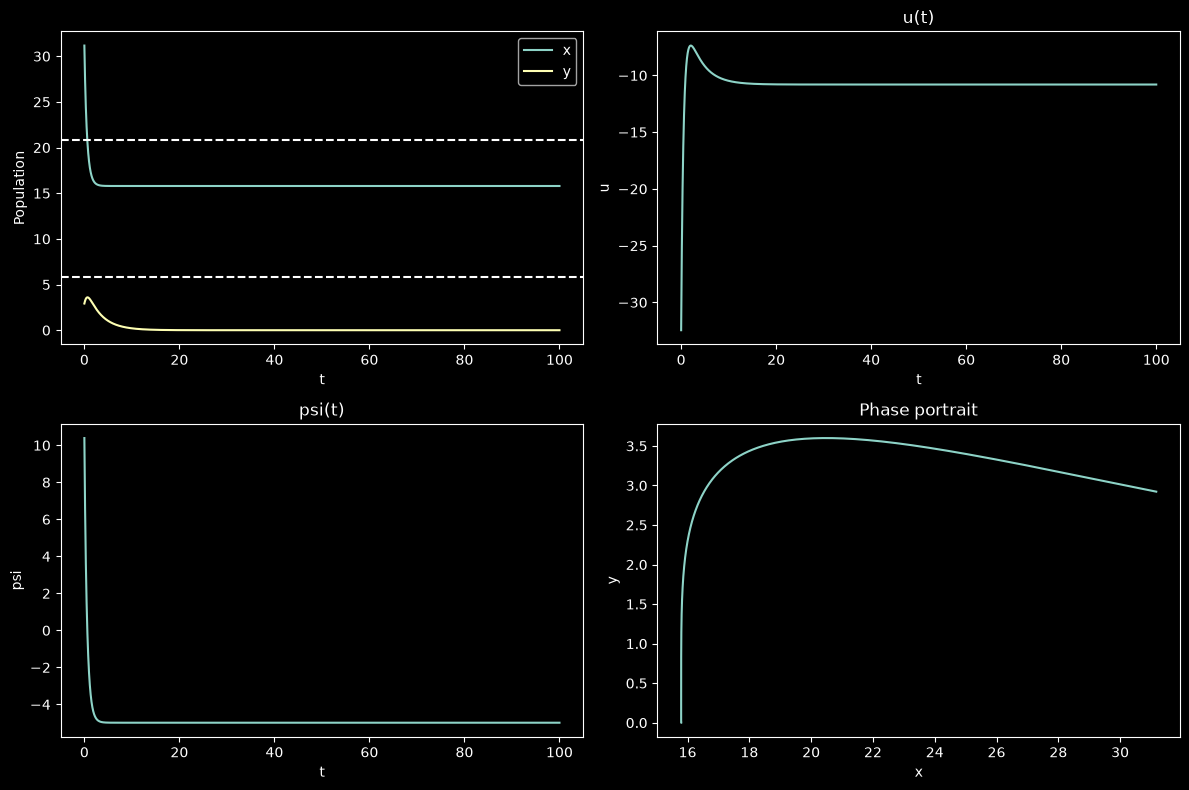

In [17]:
plot_experiment(
    competition_result
)

После добавления внутривидовой конкуренции поведение системы заметно изменилось по сравнению с классической моделью Лотки–Вольтерра. Популяция жертв быстро уменьшается и стабилизируется на уровне, отличном от расчетного равновесия, а численность хищников постепенно снижается практически до нуля.

График ошибки показывает, что после переходного процесса отклонение перестает изменяться и остается практически постоянным. Это связано с тем, что в рамках задания закон управления не изменялся и был подготовлен для классической модели Лотки–Вольтерра. После добавления членов внутривидовой конкуренции динамика системы изменилась, поэтому регулятор уже не обеспечивает точное достижение нового положения равновесия.

Управляющее воздействие имеет выраженный переходный процесс: в начале моделирования регулятор создает значительное воздействие, после чего управление быстро стабилизируется и далее поддерживается практически на постоянном уровне.

Фазовый портрет также существенно отличается от классической модели. Вместо движения к точке сосуществования двух популяций траектория приводит систему в режим, при котором численность жертв стабилизируется, а популяция хищников постепенно уменьшается почти до нуля.

Добавление внутривидовой конкуренции существенно изменяет динамику системы. При этом разработанный фреймворк не потребовал изменений в механизмах запуска экспериментов, вычисления метрик, сохранения результатов и построения графиков, что подтверждает его расширяемость. Полученный результат также показывает, что применение закона управления, синтезированного для классической модели, к модифицированной системе может приводить к появлению установившейся ошибки.


# Серия вычислительных экспериментов (аддитивное управление)

После проверки работы фреймворка проведём серию вычислительных экспериментов для исследования влияния параметра регулятора **T** на качество управления системой.

В ходе исследования параметр **T** изменяется в диапазоне от **0.1** до **5.0**. Для каждого значения автоматически выполняются:

- моделирование замкнутой системы;
- вычисление всех метрик качества управления;
- сохранение результатов эксперимента для последующего анализа и сравнения.


In [18]:
results = []

T_values = np.linspace(0.1, 5.0, 20)

Path("results").mkdir(exist_ok=True)

for T in T_values:

    cfg = ExperimentConfig(
        name=f"T={T:.2f}",
        control=ControlParams(T=T)
    )

    result = run_experiment(cfg)

    results.append(result)

print(f"Выполнено экспериментов: {len(results)}")

Выполнено экспериментов: 20


# Сохранение результатов

Все выполненные эксперименты сохраняются в отдельные JSON-файлы.

Дополнительно создаётся общий CSV-файл, содержащий вычисленные метрики всех экспериментов.

In [19]:
for result in results:

    filename = f"results/{result.config.name.replace('=', '_')}.json"

    save_experiment(
        result,
        filename
    )

save_metrics_csv(
    results,
    "results/all_metrics.csv"
)

print("Все эксперименты успешно сохранены.")

Все эксперименты успешно сохранены.


In [20]:
print("Содержимое папки results:\n")

for file in sorted(Path("results").glob("*")):
    print(file.name)

Содержимое папки results:

all_metrics.csv
experiment.json
T_0.10.json
T_0.36.json
T_0.62.json
T_0.87.json
T_1.13.json
T_1.39.json
T_1.65.json
T_1.91.json
T_2.16.json
T_2.42.json
T_2.68.json
T_2.94.json
T_3.19.json
T_3.45.json
T_3.71.json
T_3.97.json
T_4.23.json
T_4.48.json
T_4.74.json
T_5.00.json


Все результаты серии экспериментов успешно сохранены.

Для каждого значения параметра **T** сформирован отдельный JSON-файл с конфигурацией и вычисленными метриками.

Кроме того, создан общий CSV-файл, позволяющий выполнять дальнейший анализ результатов.

#  Сравнение результатов
##  Макропеременная ψ(t)

Сравним изменение макропеременной ψ(t) при различных значениях параметра T.


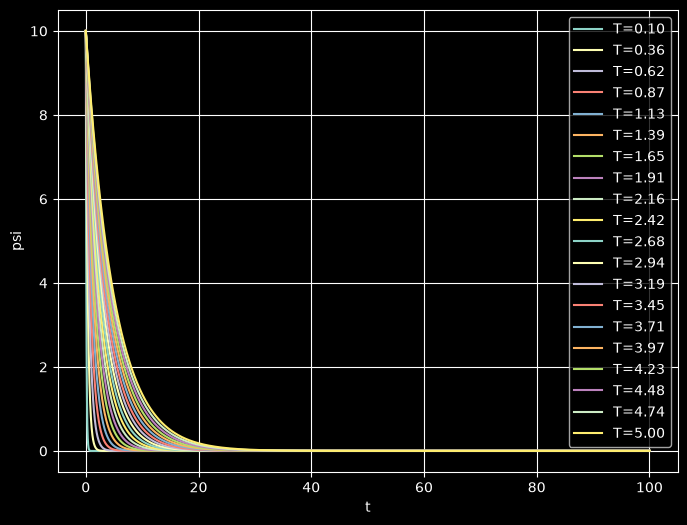

In [21]:
plot_compare(
    results,
    metric="psi"
)

Из графика видно, что параметр **T** существенно влияет на скорость уменьшения ошибки управления. При небольших значениях **T** ошибка $\psi(t)$ затухает значительно быстрее, поэтому система быстрее достигает положения равновесия.

С увеличением значения **T** переходный процесс становится более продолжительным: ошибка уменьшается медленнее, а время достижения равновесия возрастает. При этом характер изменения остаётся одинаковым для всех экспериментов — ошибка монотонно стремится к нулю без колебаний.

Таким образом, уменьшение параметра **T** позволяет ускорить работу системы, однако дальнейший анализ управляющего воздействия покажет, как это влияет на величину управления.

##  Изменение популяции жертв x(t)

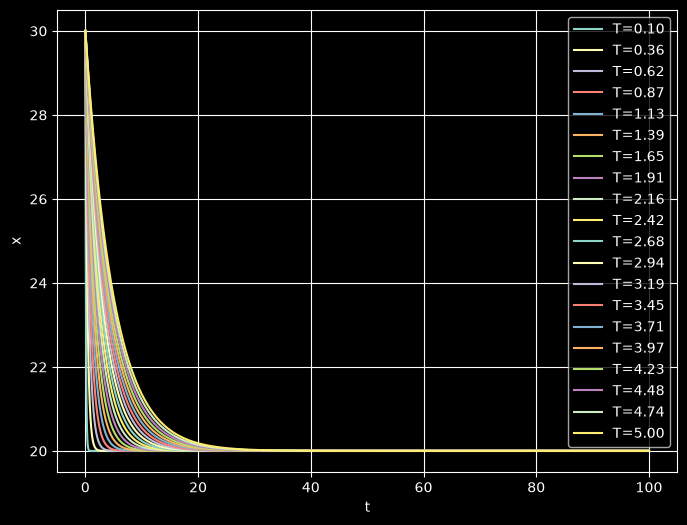

In [22]:
plot_compare(
    results,
    metric="x"
)

График показывает влияние параметра **T** на изменение численности жертв. Во всех экспериментах система сходится к одному и тому же равновесному значению $x^*=20$, однако скорость достижения этого состояния зависит от выбранного значения **T**.

При небольших значениях **T** численность жертв уменьшается значительно быстрее, поэтому переходный процесс завершается за меньшее время. С увеличением параметра **T** системе требуется больше времени для достижения равновесия.

При этом для всех рассмотренных значений **T** переходный процесс протекает плавно, без колебаний.

## Управляющее воздействие u(t)

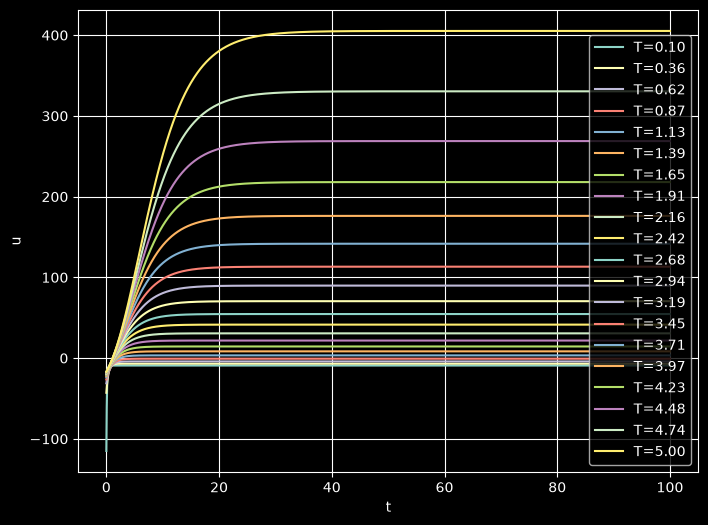

In [23]:
plot_compare(
    results,
    metric="u"
)

Из графика видно, что параметр **T** оказывает заметное влияние на величину управляющего воздействия. При малых значениях **T** управление быстро выходит на небольшой установившийся уровень. С увеличением параметра **T** величина управляющего воздействия возрастает, а переходный процесс становится более продолжительным.

Во всех рассмотренных экспериментах наблюдается одинаковый характер изменения управления: после начального переходного процесса значение $u(t)$ постепенно стабилизируется.

Предположительно, такое поведение связано с тем, что в рассматриваемой реализации управление формируется только для стабилизации переменной $x$. При больших значениях параметра **T** система дольше находится в переходном режиме, вследствие чего изменяется состояние второй переменной модели, что приводит к увеличению требуемого управляющего воздействия.


# Сводная таблица результатов

In [24]:
summary_table(results)

      name         T        tau  max_psi       max_u       e_final
0   T=0.10  0.100000   0.470047     10.0  115.000000  1.164453e-07
1   T=0.36  0.357895   1.650165     10.0   42.941176  4.290159e-07
2   T=0.62  0.615789   2.840284     10.0   31.239316  3.172020e-07
3   T=0.87  0.873684   4.030403     10.0   26.445783  1.413423e-07
4   T=1.13  1.131579   5.220522     10.0   23.837209  7.467875e-07
5   T=1.39  1.389474   6.400640     10.0   22.196970  1.306602e-07
6   T=1.65  1.647368   7.590759     10.0   21.070288  4.996629e-08
7   T=1.91  1.905263   8.780878     10.0   21.743033  2.526228e-07
8   T=2.16  2.163158   9.970997     10.0   30.650728  7.191698e-08
9   T=2.42  2.421053  11.151115     10.0   41.459269  2.240393e-07
10  T=2.68  2.678947  12.341234     10.0   54.574282  7.067412e-08
11  T=2.94  2.936842  13.531353     10.0   70.487956  4.168185e-08
12  T=3.19  3.194737  14.721472     10.0   89.797504  2.036376e-08
13  T=3.45  3.452632  15.901590     10.0  113.227589  1.368666

Из сводной таблицы видно, что увеличение параметра **T** приводит к увеличению времени сходимости системы. Так, при **T = 0.1** время сходимости составляет около **0.47**, а при **T = 5.0** возрастает до **23.03**. Это подтверждает, что при больших значениях **T** переходный процесс протекает медленнее.

Максимальная ошибка во всех экспериментах остаётся одинаковой и равна **10**, поскольку система во всех случаях запускается из одного и того же начального состояния. Остаточная ошибка также имеет порядок **10⁻⁷–10⁻⁹**, что свидетельствует о высокой точности численного решения и успешном достижении заданного режима.

Интересно, что зависимость максимального управляющего воздействия от параметра **T** имеет нелинейный характер. При увеличении **T** значение **max|u|** сначала уменьшается, достигая минимального значения при **T ≈ 1.6–1.9**, а затем начинает быстро возрастать. Предположительно, это связано с особенностями выбранного закона управления, который стабилизирует только переменную $x$. При больших значениях **T** системе требуется больше времени для достижения равновесия, что приводит к увеличению максимального управляющего воздействия.



In [25]:
best = next(r for r in results if r.config.name == "T=1.65")

In [26]:

print("Лучший эксперимент:")

print(f"Название:               {best.config.name}")
print(f"T:                      {best.config.control.T:.2f}")
print(f"Время сходимости:       {best.metrics.tau:.6f}")
print(f"Максимальное |ψ|:       {best.metrics.max_psi:.6f}")
print(f"Максимальное |u|:       {best.metrics.max_u:.6f}")
print(f"Остаточная ошибка:      {best.metrics.e_final:.6e}")

Лучший эксперимент:
Название:               T=1.65
T:                      1.65
Время сходимости:       7.590759
Максимальное |ψ|:       10.000000
Максимальное |u|:       21.070288
Остаточная ошибка:      4.996629e-08


Наиболее предпочтительным оказался эксперимент с T=1.65, поскольку при этом значении параметра регулятора достигается минимальная величина максимального управляющего воздействия при сохранении приемлемого времени сходимости и практически нулевой остаточной ошибки.

При T=0.1 система действительно сходится быстрее всего, однако для этого требуется значительно большее управляющее воздействие (∣u∣
max=115). В реальных системах исполнительные механизмы имеют ограничения по мощности, поэтому столь большие значения управления нежелательны.

#  Воспроизведение лучшего эксперимента

Проверим возможность полного воспроизведения эксперимента только по сохранённому JSON-файлу.

In [27]:
best_path = f"results/{best.config.name.replace('=', '_')}.json"

print("Загружается файл:")

print(best_path)

best_loaded = load_and_reproduce(best_path)

Загружается файл:
results/T_1.65.json


In [28]:
print("Исходный эксперимент")
print(f"Время сходимости (τ):       {best.metrics.tau:.6f}")
print(f"Максимальное |ψ|:           {best.metrics.max_psi:.6f}")
print(f"Максимальное |u|:           {best.metrics.max_u:.6f}")
print(f"Остаточная ошибка:          {best.metrics.e_final:.6e}")



print("\nВоспроизведённый эксперимент")
print(f"Время сходимости (τ):       {best_loaded.metrics.tau:.6f}")
print(f"Максимальное |ψ|:           {best_loaded.metrics.max_psi:.6f}")
print(f"Максимальное |u|:           {best_loaded.metrics.max_u:.6f}")
print(f"Остаточная ошибка:          {best_loaded.metrics.e_final:.6e}")

Исходный эксперимент
Время сходимости (τ):       7.590759
Максимальное |ψ|:           10.000000
Максимальное |u|:           21.070288
Остаточная ошибка:          4.996629e-08

Воспроизведённый эксперимент
Время сходимости (τ):       7.590759
Максимальное |ψ|:           10.000000
Максимальное |u|:           21.070288
Остаточная ошибка:          4.996629e-08


In [29]:
print("\nСовпадение метрик\n")

print(
    abs(best.metrics.tau - best_loaded.metrics.tau) < 1e-8,
    abs(best.metrics.max_psi - best_loaded.metrics.max_psi) < 1e-8,
    abs(best.metrics.max_u - best_loaded.metrics.max_u) < 1e-8,
    abs(best.metrics.e_final - best_loaded.metrics.e_final) < 1e-8
)


Совпадение метрик

True True True True


Эксперимент был успешно воспроизведён по сохранённой конфигурации.

Совпадение всех вычисленных метрик подтверждает корректность реализации функций сохранения и загрузки результатов, а также воспроизводимость вычислительных экспериментов.

# Символьный вывод закона управления с помощью SymPy

Помимо численного моделирования во фреймворке реализован универсальный модуль символьного вывода закона управления с использованием библиотеки **SymPy**.

Модуль принимает на вход:

- символьные уравнения модели;
- макропеременную $\psi(x,y)$;
- параметр регулятора $T$.

После этого автоматически выполняются следующие этапы:

1. вычисляется производная макропеременной $\dot{\psi}$;
2. формируется условие АКАР $\dot{\psi}=-\psi/T$;
3. выполняется решение полученного уравнения относительно управления $u$;
4. формируется лямбда-функция для последующего численного вычисления управления.



In [30]:
# Объявление символьных переменных состояния
x, y = sp.symbols("x y")

alpha, beta = sp.symbols("alpha beta")
delta, gamma = sp.symbols("delta gamma")
u = sp.symbols("u")
T = sp.symbols("T")
x_star = sp.symbols("x_star")

# Правая часть первого уравнения модели:
# x' = αx − βxy + u
f = alpha * x - beta * x * y + u

# Правая часть второго уравнения модели:
# y' = δxy − γy
g = delta * x * y - gamma * y

# Выбранная макропеременная
psi = x - x_star

In [31]:
# Символьный вывод закона управления
print("Правая часть ẋ:")
sp.pprint(f)
print("\nПравая часть ẏ:")
sp.pprint(g)
print("\nМакропеременная ψ:")
sp.pprint(psi)

# Получение закона управления разработанным модулем
u_expr, u_func = derive_control_symbolic(
    x,
    y,
    f,
    g,
    psi,
    u,
    T
)

print("\nЗакон управления, полученный символьным модулем:")
sp.pprint(u_expr)

# Аналитическая формула
expected = (
    -(x - x_star) / T
    - alpha * x
    + beta * x * y
)

print("\nАналитическая формула:")
sp.pprint(expected)

# Сравнение результатов
print("\nСовпадает ли символьный вывод с аналитическим?")

print(
    sp.simplify(u_expr - expected) == 0
)

Правая часть ẋ:
α⋅x - β⋅x⋅y + u

Правая часть ẏ:
δ⋅x⋅y - γ⋅y

Макропеременная ψ:
x - xₛₜₐᵣ

Закон управления, полученный символьным модулем:
-T⋅x⋅(α - β⋅y) - x + xₛₜₐᵣ
──────────────────────────
            T             

Аналитическая формула:
               -x + xₛₜₐᵣ
-α⋅x + β⋅x⋅y + ──────────
                   T     

Совпадает ли символьный вывод с аналитическим?
True


## Второй пример работы для ψ = x/y - c*

In [32]:
# Символьный вывод для ψ = x/y - c*
c_star = sp.symbols("c_star")
psi2 = x / y - c_star

u_expr2, u_func2 = derive_control_symbolic(
    x,
    y,
    f,
    g,
    psi2,
    u,
    T
)

print("Макропеременная:")
sp.pprint(psi2)

print("\nЗакон управления, полученный символьным модулем:")
sp.pprint(u_expr2)

# Аналитическая формула (полученная вручную)
expected2 = (
    -alpha * x
    + beta * x * y
    + delta * x**2
    - gamma * x
    - x / T
    + c_star * y / T
)

print("\nАналитическая формула:")
sp.pprint(expected2)

print("\nСовпадает ли символьный вывод с аналитическим?")
print(sp.simplify(u_expr2 - expected2) == 0)

Макропеременная:
         x
-cₛₜₐᵣ + ─
         y

Закон управления, полученный символьным модулем:
-T⋅x⋅(α - β⋅y - δ⋅x + γ) + cₛₜₐᵣ⋅y - x
──────────────────────────────────────
                  T                   

Аналитическая формула:
                  2         cₛₜₐᵣ⋅y   x
-α⋅x + β⋅x⋅y + δ⋅x  - γ⋅x + ─────── - ─
                               T      T

Совпадает ли символьный вывод с аналитическим?
True


## Использование lambda-функции


In [33]:
import inspect


print("\nАргументы lambda-функции:")
print(inspect.signature(u_func))

# Численное вычисление управления
u_value = u_func(
    30.0,   # x
    10.0,   # y
    2.0,    # T
    1.0,    # alpha
    0.1,    # beta
    20.0    # x_star
)

print("\nПример численного вычисления закона управления")

print(f"x       = {30.0}")
print(f"y       = {10.0}")
print(f"T       = {2.0}")
print(f"alpha   = {1.0}")
print(f"beta    = {0.1}")
print(f"x_star  = {20.0}")

print(f"\nПолученное значение управления:")
print(f"u = {u_value:.6f}")


Аргументы lambda-функции:
(x, y, T, alpha, beta, x_star)

Пример численного вычисления закона управления
x       = 30.0
y       = 10.0
T       = 2.0
alpha   = 1.0
beta    = 0.1
x_star  = 20.0

Полученное значение управления:
u = -5.000000
